# GREENLY - Processed Dataset Validation

Inspects the six *processed* training datasets built by `../scripts/prepare_datasets.py` from the raw sources explored in notebook 01. Full methodology and cited constants are in `../DATASETS.md` - this notebook validates the *result*: distributions, missing values, and feature/target relationships.

Run `python ../scripts/prepare_datasets.py` first if `../data/processed/` is empty.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
PROCESSED = Path('..') / 'data' / 'processed'
CATEGORIES = ['carbon', 'energy', 'electronics', 'water', 'food', 'waste']
datasets = {c: pd.read_csv(PROCESSED / f'{c}.csv') for c in CATEGORIES}
for c, df in datasets.items():
    print(f'{c:12s} {len(df):>7,} rows   {df.isna().sum().sum()} missing values')

carbon        67,189 rows   0 missing values
energy        12,000 rows   0 missing values
electronics    8,000 rows   0 missing values
water          8,000 rows   0 missing values
food           8,000 rows   0 missing values
waste          8,000 rows   0 missing values


## Target distributions
What each model is learning to predict.

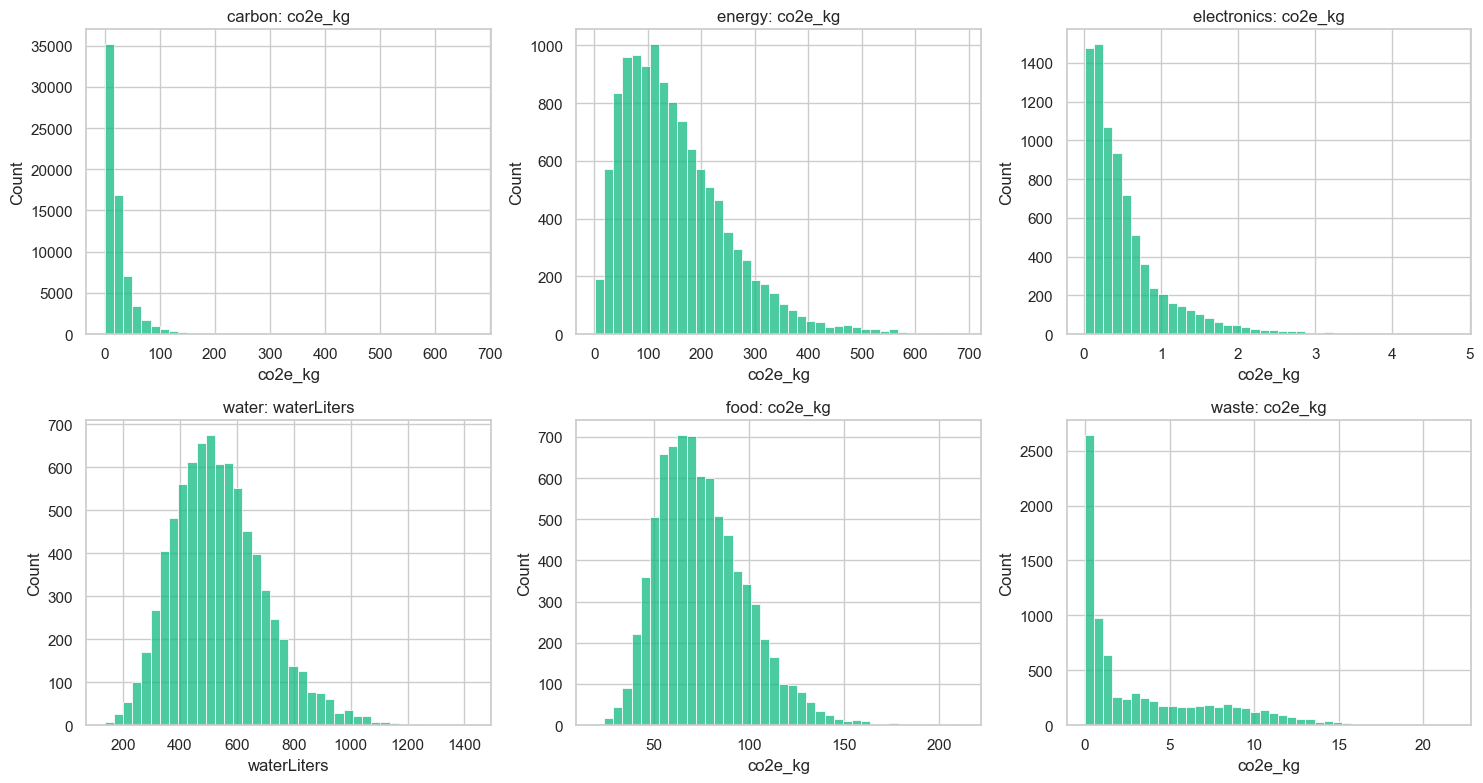

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
targets = {'carbon': 'co2e_kg', 'energy': 'co2e_kg', 'electronics': 'co2e_kg',
           'water': 'waterLiters', 'food': 'co2e_kg', 'waste': 'co2e_kg'}
for ax, (cat, target) in zip(axes.flat, targets.items()):
    sns.histplot(datasets[cat][target], bins=40, ax=ax, color='#10b981')
    ax.set_title(f'{cat}: {target}')
plt.tight_layout(); plt.show()

## Feature-target relationships (Carbon example)
Distance should dominate; this is what lets the model learn a real, non-arbitrary relationship instead of a fixed multiplier.

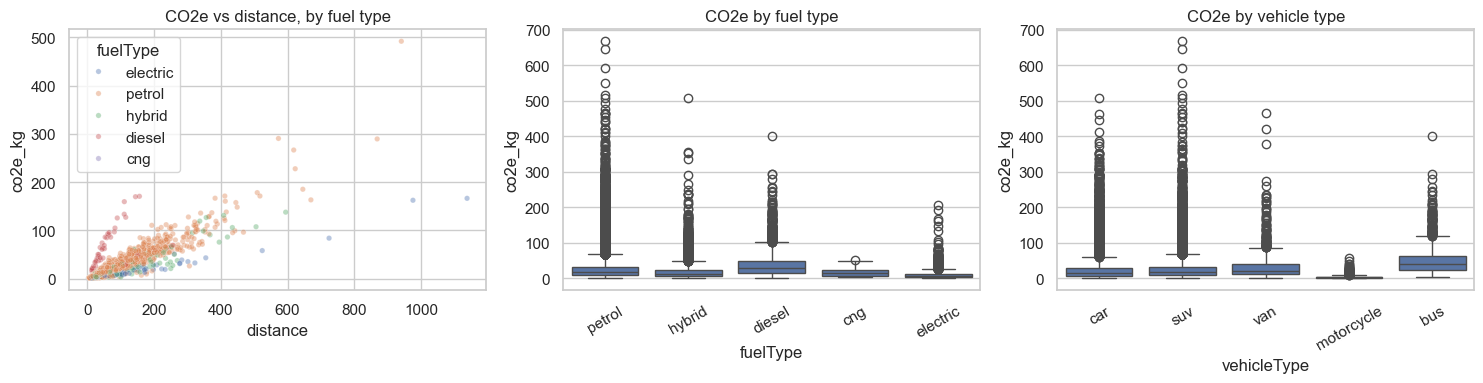

In [3]:
carbon = datasets['carbon']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=carbon.sample(2000, random_state=1), x='distance', y='co2e_kg', hue='fuelType', ax=axes[0], alpha=0.4, s=15)
axes[0].set_title('CO2e vs distance, by fuel type')
sns.boxplot(data=carbon, x='fuelType', y='co2e_kg', ax=axes[1])
axes[1].set_title('CO2e by fuel type'); axes[1].tick_params(axis='x', rotation=30)
sns.boxplot(data=carbon, x='vehicleType', y='co2e_kg', ax=axes[2])
axes[2].set_title('CO2e by vehicle type'); axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## Correlation check (Food example)
Food's model has the lowest R^2 (0.57) of the six - here's why: even after switching from a single random food item per row to bucket-average intensities, real diet-composition variance remains. This is a genuine, disclosed limitation (see DATASETS.md), not a bug.

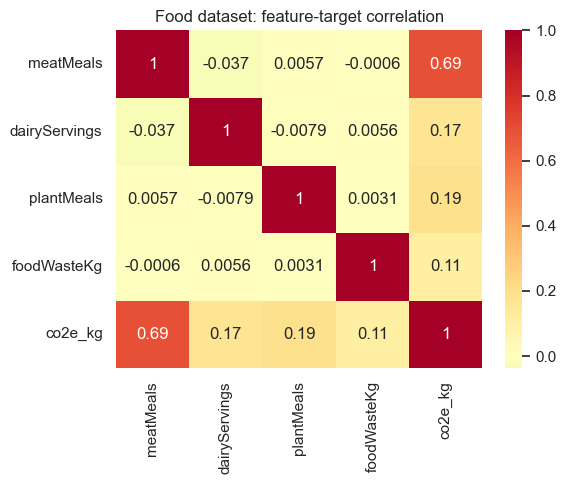

In [4]:
food = datasets['food']
numeric = food[['meatMeals', 'dairyServings', 'plantMeals', 'foodWasteKg', 'co2e_kg']]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(numeric.corr(), annot=True, cmap='RdYlGn_r', center=0, ax=ax)
ax.set_title('Food dataset: feature-target correlation')
plt.tight_layout(); plt.show()

## Outlier / range sanity check

In [5]:
summary = pd.DataFrame({c: datasets[c][targets[c]].describe() for c in CATEGORIES}).T
summary[['count', 'mean', 'std', 'min', 'max']].round(2)

,count,mean,std,min,max
carbon,67189.0,25.43,31.34,0.10,667.07
energy,12000.0,151.24,98.62,0.59,688.52
electronics,8000.0,0.53,0.54,0.01,4.78
water,8000.0,538.38,161.87,135.40,1427.30
food,8000.0,75.66,23.38,19.03,212.09
waste,8000.0,3.39,3.98,0.00,21.72
